# Repair Results Analysis

This notebook loads repair results from SQLite databases and generates summary statistics and visualizations.


In [34]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
%matplotlib inline

In [36]:
database_version = "2"

In [37]:
target_db = f'targets{database_version}.db'

In [38]:
sources_dbs = [
            #     "repair_results_claude_claude-opus-4-20250514_targets.db",
            #    "repair_results_claude_claude-sonnet-4-20250514_targets.db",
               f"repair_results_gemini_gemini-2.5-flash_targets{database_version}.db",
               f"repair_results_gemini_gemini-2.5-pro_targets{database_version}.db",
               f"repair_results_openai_o3-2025-04-16_targets{database_version}.db",
               f"repair_results_openai_o4-mini-2025-04-16_targets{database_version}.db",

               ]

In [39]:
import sqlite3
conn = sqlite3.connect(target_db)
df_cases = pd.read_sql(
    "SELECT id, num_nonterminals, nonterminal_prob, loop_prob, mutation_depth, original_parser, corrupted_grammar FROM cases",
    conn
)

# Compute derived columns for analysis
df_cases['parser_size'] = df_cases['original_parser'].str.len()
df_cases['corrupted_symbol_count'] = df_cases['corrupted_grammar'].str.split().str.len()

In [40]:

# plt.figure(figsize=(8, 6))
# sns.scatterplot(data=df_cases, x='corrupted_symbol_count', y='parser_size')
# sns.regplot(data=df_cases, x='corrupted_symbol_count', y='parser_size', scatter=False, color='red', label='Fit line')
# plt.legend()
# plt.xlabel('Symbol Count')
# plt.ylabel('Parser Size')
# plt.tight_layout()


/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_87666/2092731403.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_fixes, x="model", y="accuracy", palette="tab10")


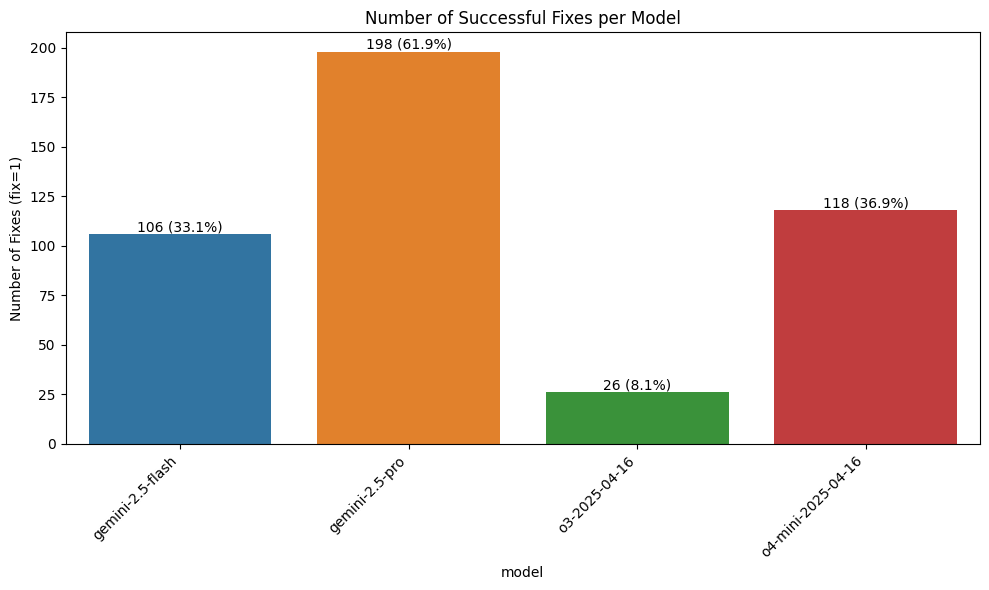

In [41]:
counts = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix("repair_results_").removesuffix("_targets.db").split("_")[1]
    conn = sqlite3.connect(db_path)
    cnt = 0
    try:
        cnt = pd.read_sql(
            "SELECT COUNT(*) AS fixes FROM repair_results WHERE fix = 1",
            conn
        )["fixes"].iloc[0]
    except pd.io.sql.DatabaseError:
        cnt = 0
    finally:
        conn.close()
    counts.append({"model": model, "accuracy": cnt})

df_fixes = pd.DataFrame(counts)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_fixes, x="model", y="accuracy", palette="tab10")
# Annotate accuracy and percentages (of total test cases) on top of each bar
total = len(df_cases)
for i, v in enumerate(df_fixes['accuracy']):
    pct = v / total * 100
    plt.text(i, v, f"{v} ({pct:.1f}%)", ha='center', va='bottom')
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy (fix=1)")
plt.title("Accuracy per Model")
plt.tight_layout()

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_87666/2581659869.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_okcases, x='model', y='corrupted_symbol_count', palette='tab10')


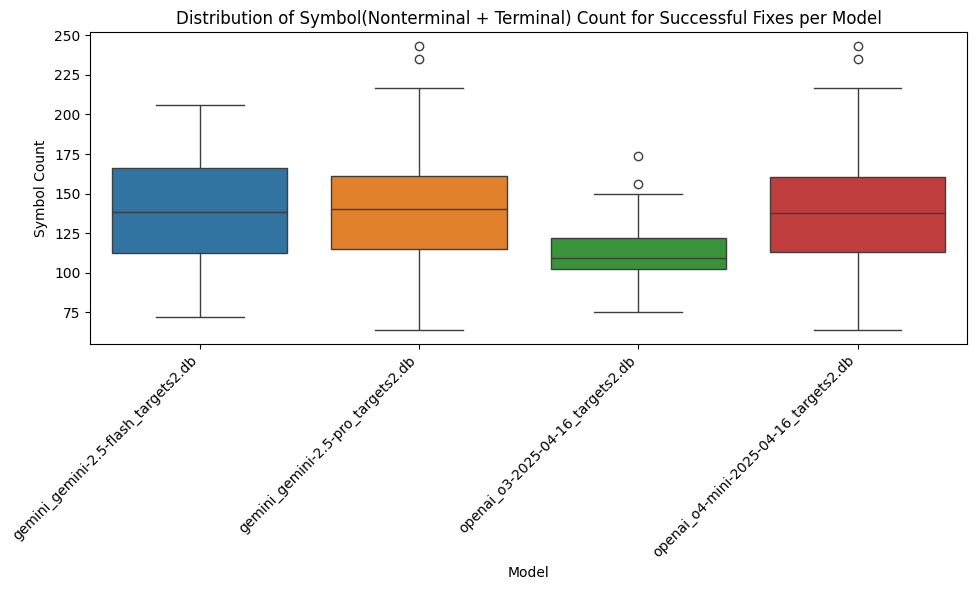

In [42]:
# Distribution of corrupted_symbol_count for successful fixes per model
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix('_targets.db')
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT case_id, fix FROM repair_results',
        conn
    )
    conn.close()
    df_ok = df_res[df_res['fix'] == 1].merge(
        df_cases[['id', 'corrupted_symbol_count']], left_on='case_id', right_on='id'
    )
    for cs in df_ok['corrupted_symbol_count']:
        records.append({'model': model, 'corrupted_symbol_count': cs})

df_okcases = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_okcases, x='model', y='corrupted_symbol_count', palette='tab10')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Model')
plt.ylabel('Symbol Count')
plt.title('Distribution of Symbol(Nonterminal + Terminal) Count for Successful Fixes per Model')
plt.tight_layout()


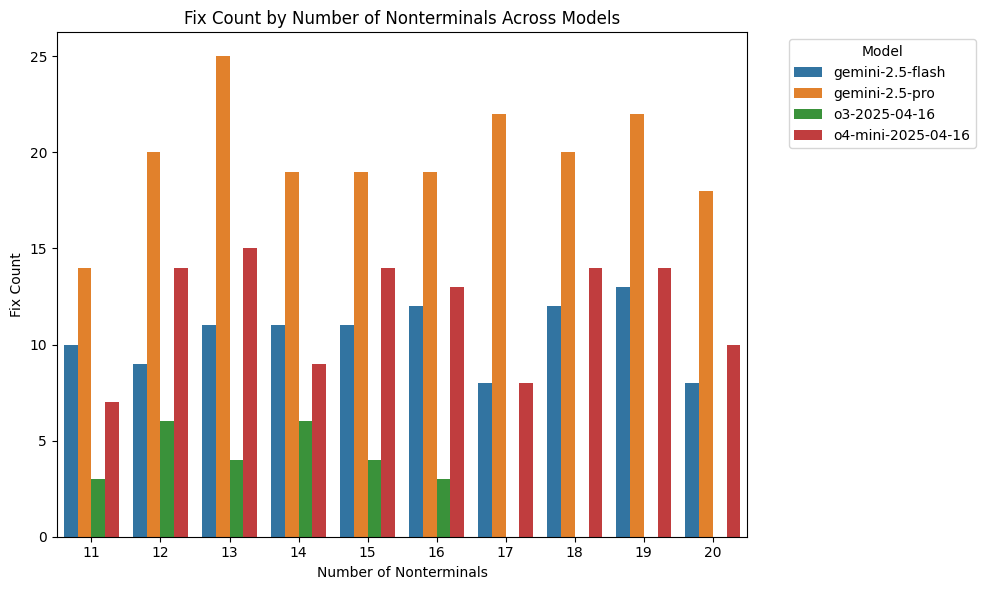

In [43]:
# Bar plot of accuracy by number of nonterminals across all models
# Ensure num_nonterminals is integer for correct sorting and plotting
df_cases['num_nonterminals'] = pd.to_numeric(df_cases['num_nonterminals'], errors='coerce')
df_cases = df_cases.dropna(subset=['num_nonterminals'])
df_cases['num_nonterminals'] = df_cases['num_nonterminals'].astype(int)

records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix('_targets.db').split('_')[1]
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql('SELECT case_id, fix FROM repair_results', conn)
    conn.close()
    df_ok = df_res[df_res['fix'] == 1].merge(df_cases[['id','num_nonterminals']], left_on='case_id', right_on='id')
    counts = df_ok['num_nonterminals'].value_counts().sort_index()
    for num_nt, cnt in counts.items():
        records.append({'model': model, 'num_nonterminals': num_nt, 'accuracy': cnt})

df_nt_fixes = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_nt_fixes, x='num_nonterminals', y='accuracy', hue='model')
plt.xlabel('Number of Nonterminals')
plt.ylabel('Accuracy')
plt.title('Accuracy by Number of Nonterminals Across Models')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_87666/887721377.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_model, x='num_nonterminals', y='accuracy', palette='viridis')


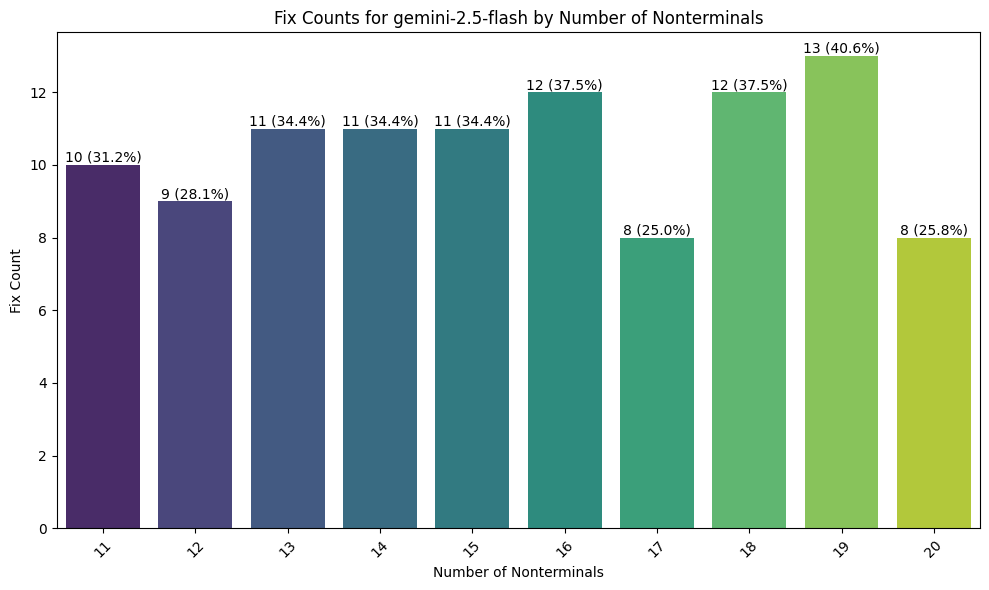

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_87666/887721377.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_model, x='num_nonterminals', y='accuracy', palette='viridis')


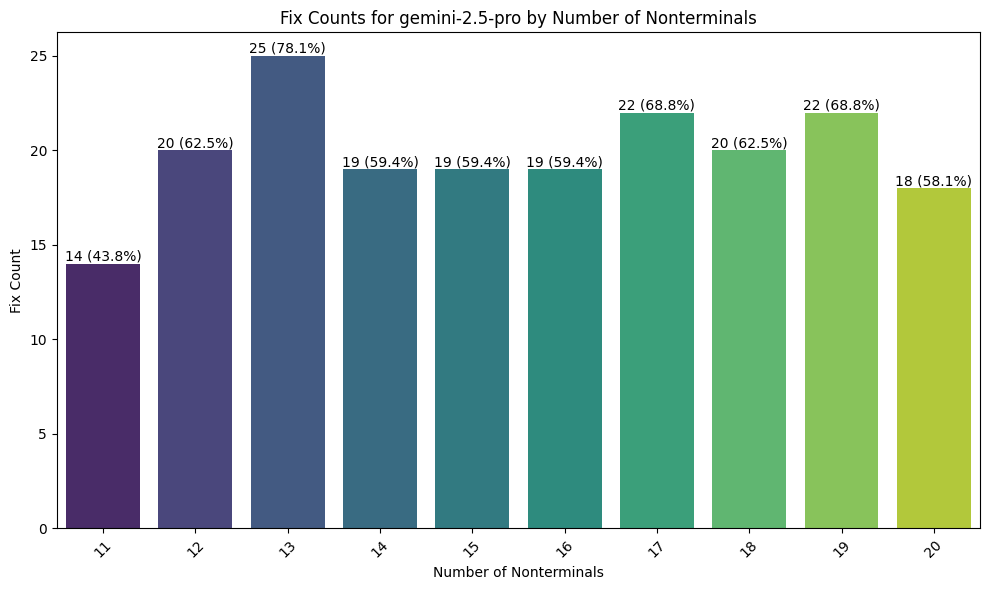

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_87666/887721377.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_model, x='num_nonterminals', y='accuracy', palette='viridis')


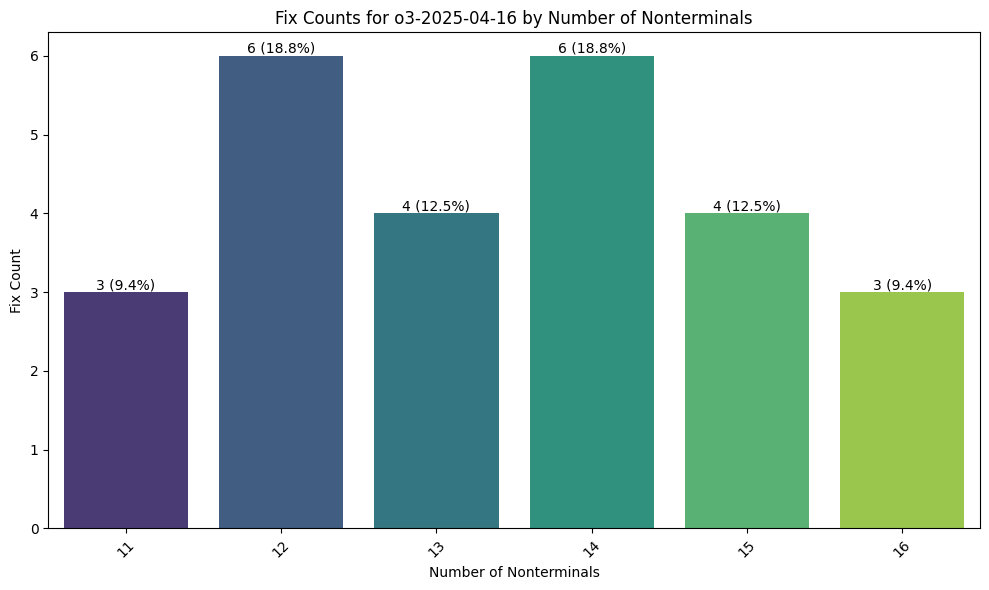

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_87666/887721377.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_model, x='num_nonterminals', y='accuracy', palette='viridis')


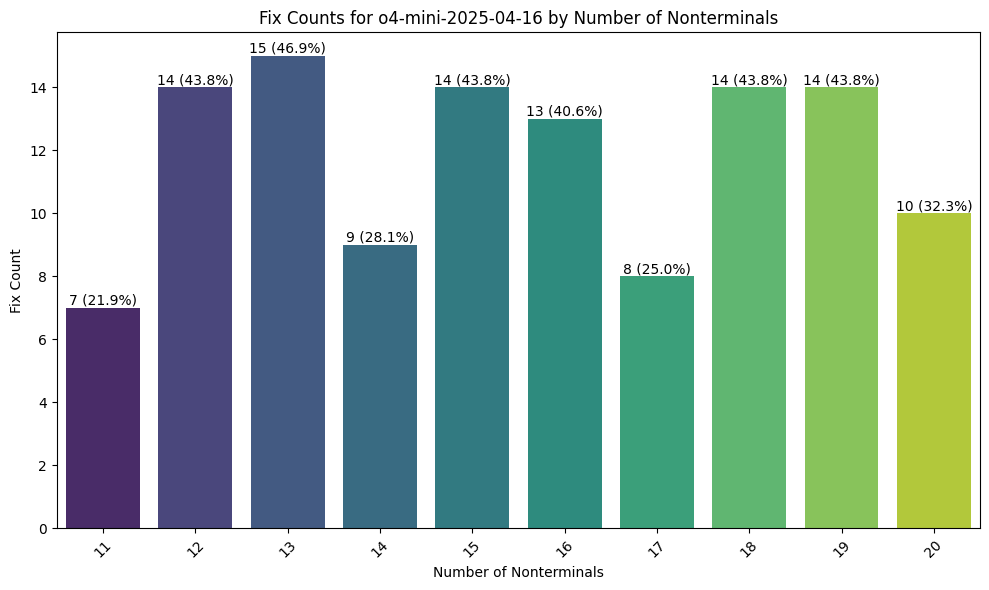

In [44]:
# generate chart for each model with accuracy by number of nonterminals
for model in df_nt_fixes['model'].unique():
    df_model = df_nt_fixes[df_nt_fixes['model'] == model]
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_model, x='num_nonterminals', y='accuracy', palette='viridis')
    for i, (num_nt, v) in enumerate(zip(df_model['num_nonterminals'], df_model['accuracy'])):
        total = len(df_cases[df_cases['num_nonterminals'] == num_nt])
        pct = v / total * 100
        plt.text(i, v, f"{v} ({pct:.1f}%)", ha='center', va='bottom')
    plt.title(f'Accuracy for {model} by Number of Nonterminals')
    plt.xlabel('Number of Nonterminals')
    plt.ylabel('Accuracy')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_87666/169938833.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_mut, x='num_nonterminals', y='mutation_depth', palette='tab10')


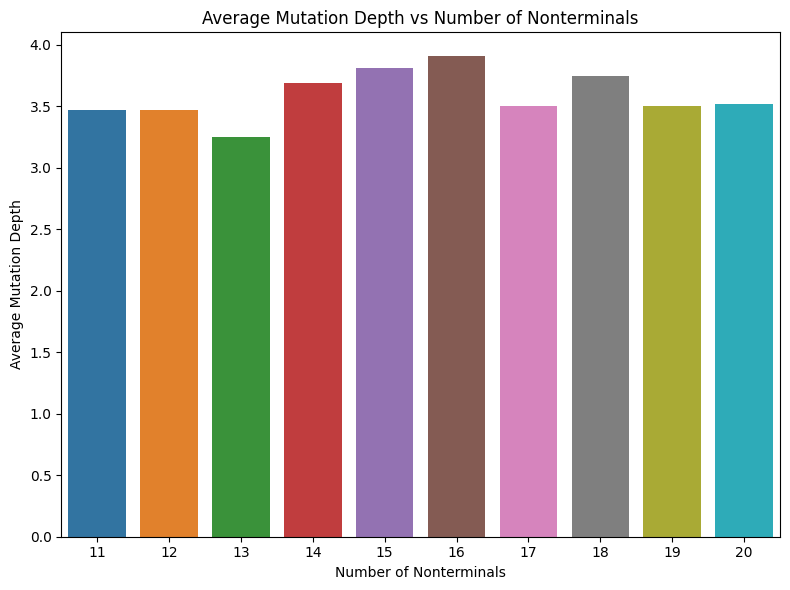

In [45]:
# Bar plot of average mutation_depth vs num_nonterminals
avg_mut = df_cases.groupby('num_nonterminals')['mutation_depth'].mean().reset_index()
plt.figure(figsize=(8, 6))
sns.barplot(data=avg_mut, x='num_nonterminals', y='mutation_depth', palette='tab10')
plt.xlabel('Number of Nonterminals')
plt.ylabel('Average Mutation Depth')
plt.title('Average Mutation Depth vs Number of Nonterminals')
plt.tight_layout()


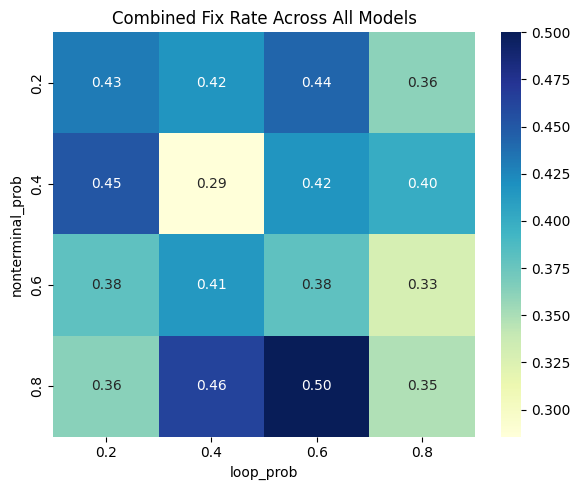

In [46]:
# Combined heatmap of fix-rate across all models by nonterminal_prob and loop_prob
records = []
for db_path in sources_dbs:
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT nonterminal_prob, loop_prob, fix FROM repair_results', conn
    )
    conn.close()
    df_res['model'] = os.path.basename(db_path)
    records.append(df_res)

df_all = pd.concat(records, ignore_index=True)

totals = df_all.groupby(['nonterminal_prob','loop_prob']).size().rename('total')
successes= df_all[df_all['fix'] == 1].groupby(['nonterminal_prob','loop_prob']).size().rename('success')
df_rate = pd.concat([totals, successes], axis=1).fillna(0)
df_rate['rate'] = df_rate['success'] / df_rate['total']
pivot = df_rate['rate'].unstack(level='loop_prob')

plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Combined Fix Rate Across All Models')
plt.xlabel('loop_prob')
plt.ylabel('nonterminal_prob')
plt.tight_layout()


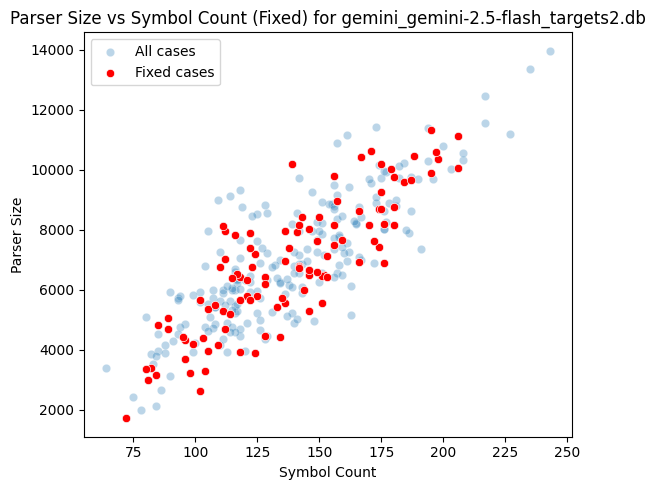

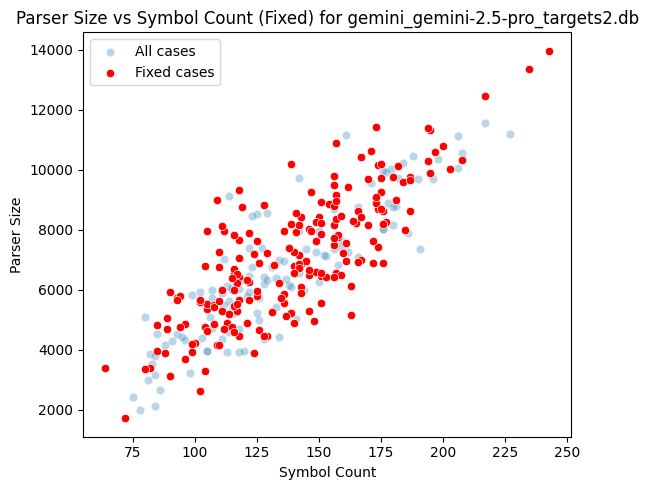

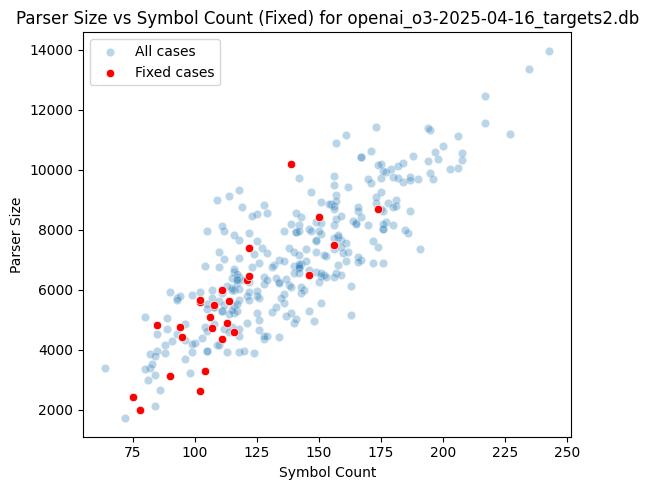

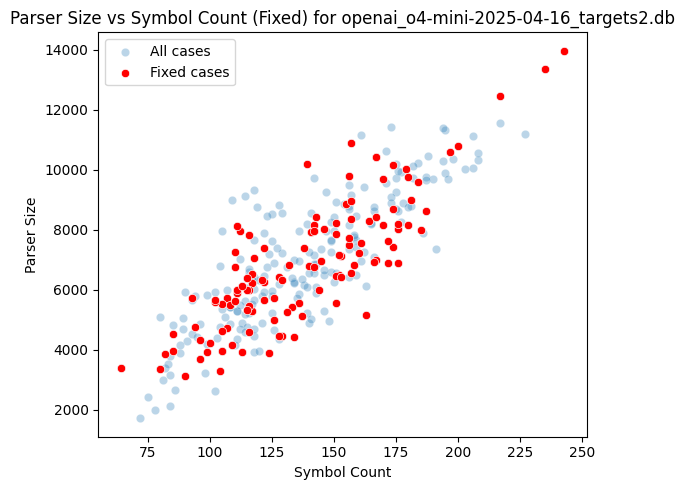

In [47]:
# Scatter plot of parser_size vs corrupted_symbol_count, highlighting fixed cases per model
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix('_targets.db')
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT case_id, fix FROM repair_results', conn
    )
    conn.close()
    fixed = df_res[df_res['fix'] == 1]['case_id']
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=df_cases, x='corrupted_symbol_count', y='parser_size', alpha=0.3, label='All cases')
    sns.scatterplot(data=df_cases[df_cases['id'].isin(fixed)], 
                    x='corrupted_symbol_count', y='parser_size', color='red', label='Fixed cases')
    plt.title(f'Parser Size vs Symbol Count (Fixed) for {model}')
    plt.xlabel('Symbol Count')
    plt.ylabel('Parser Size')
    plt.legend()
    plt.tight_layout()


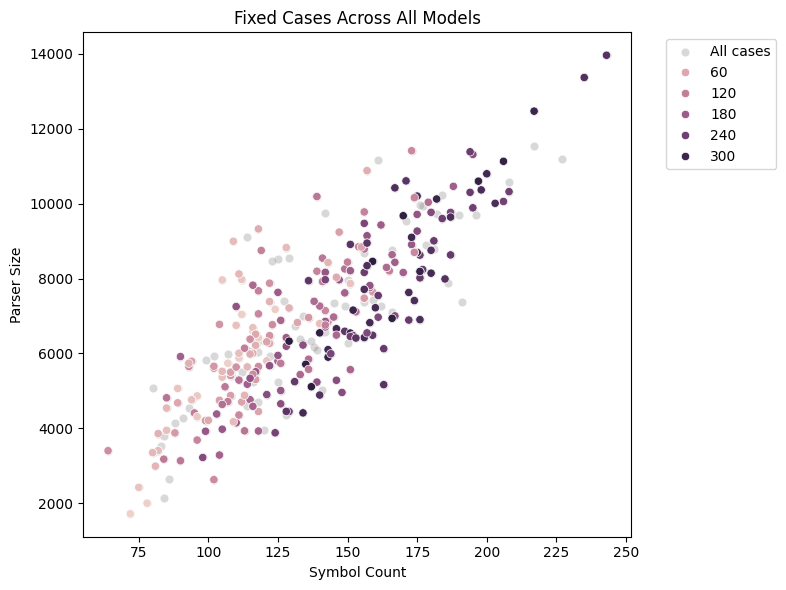

In [48]:
# Combined scatter plot of fixed cases across all models
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix('_targets.db')
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql('SELECT case_id, puzzle_id, fix, total_tokens FROM repair_results', conn)
    df_tmp = df_res[df_res['fix'] == 1].merge(df_cases, left_on='case_id', right_on='id')
    df_tmp['model'] = model
    records.append(df_tmp)
    conn.close()

df_fixed_all = pd.concat(records, ignore_index=True)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cases, x='corrupted_symbol_count', y='parser_size', color='gray', alpha=0.3, label='All cases')
sns.scatterplot(data=df_fixed_all, x='corrupted_symbol_count', y='parser_size', hue='puzzle_id')
plt.xlabel('Symbol Count')
plt.ylabel('Parser Size')
plt.title('Fixed Cases Across All Models')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


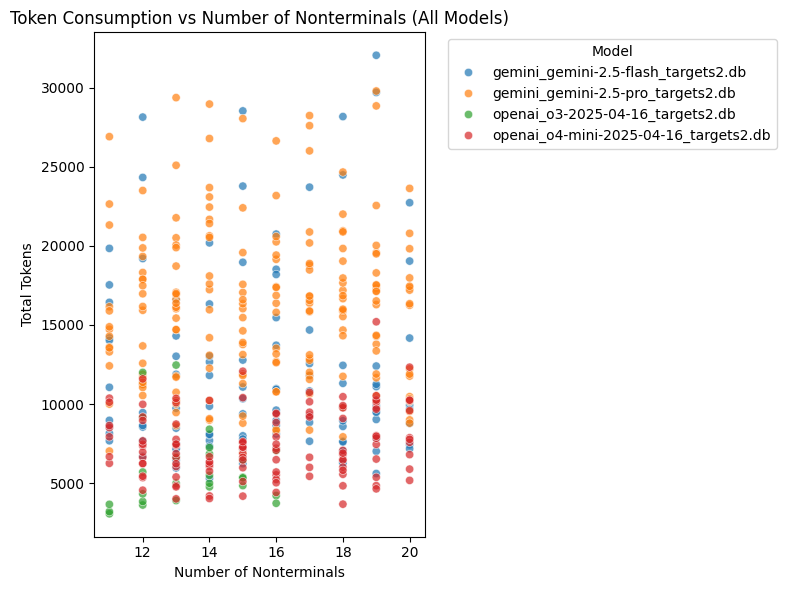

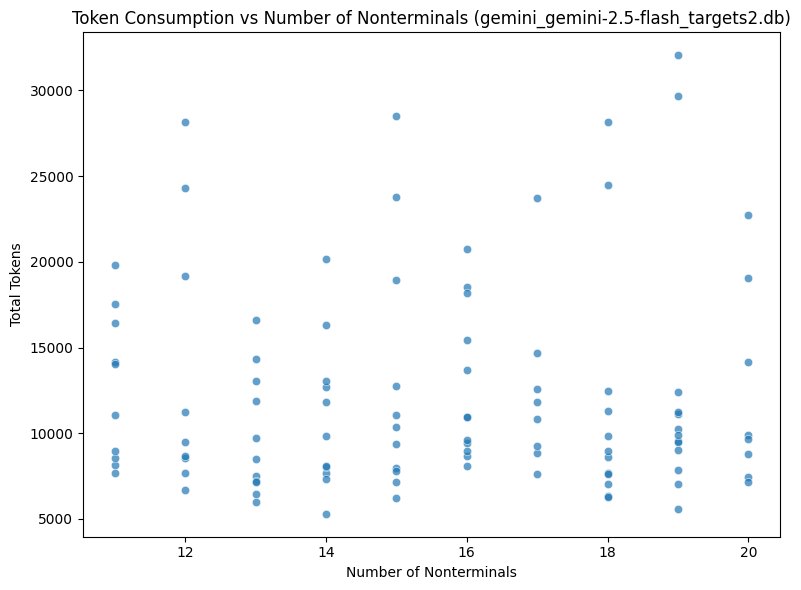

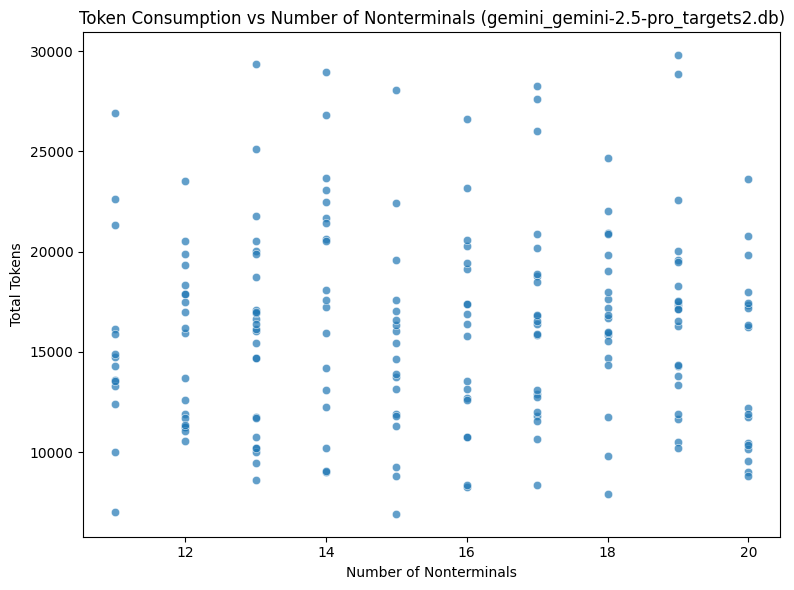

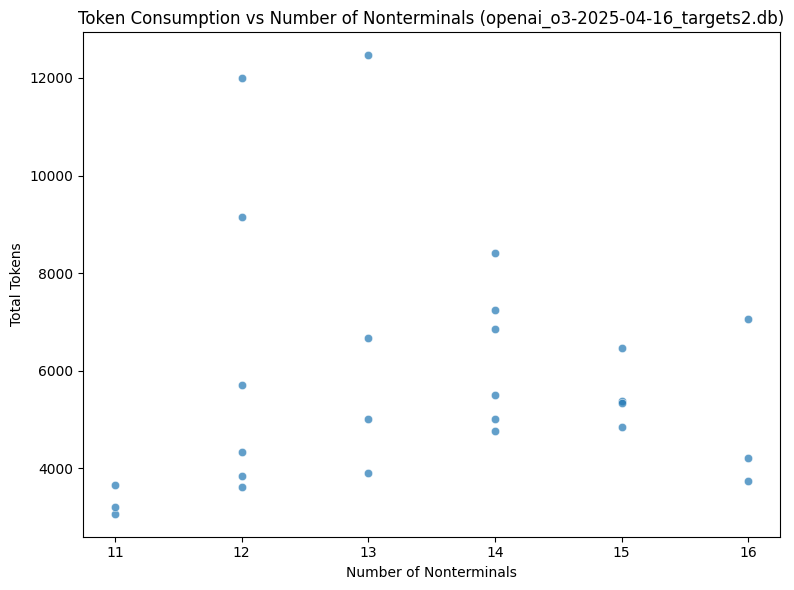

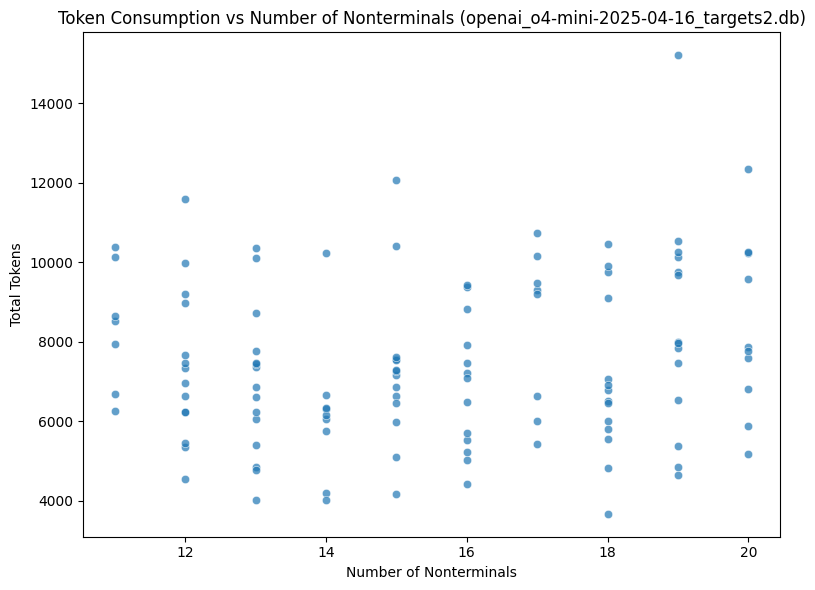

In [49]:
# Scatter plot of token consumption vs number of nonterminals across all fixed cases
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_fixed_all, x='num_nonterminals', y='total_tokens', hue='model', alpha=0.7)
plt.xlabel('Number of Nonterminals')
plt.ylabel('Total Tokens')
plt.title('Token Consumption vs Number of Nonterminals (All Models)')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Individual model plots
for model in df_fixed_all['model'].unique():
    df_mod = df_fixed_all[df_fixed_all['model'] == model]
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_mod, x='num_nonterminals', y='total_tokens', color='C0', alpha=0.7)
    plt.xlabel('Number of Nonterminals')
    plt.ylabel('Total Tokens')
    plt.title(f'Token Consumption vs Number of Nonterminals ({model})')
    plt.tight_layout()


In [50]:
# Table of fixed cases counts by mutation_depth for each model
records = []
for db_path in sources_dbs:
    model = os.path.basename(db_path).removeprefix('repair_results_').removesuffix('_targets.db')
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql('SELECT case_id, fix FROM repair_results', conn)
    conn.close()
    df_ok = df_res[df_res['fix'] == 1].merge(df_cases[['id','mutation_depth']], left_on='case_id', right_on='id')
    counts = df_ok['mutation_depth'].value_counts().sort_index()
    for depth, cnt in counts.items():
        records.append({'model': model, 'mutation_depth': depth, 'accuracy': cnt})

df_mut_counts = pd.DataFrame(records)
pivot_mut = df_mut_counts.pivot(index='mutation_depth', columns='model', values='accuracy').fillna(0).astype(int)
print(pivot_mut)


model           gemini_gemini-2.5-flash_targets2.db  \
mutation_depth                                        
2                                                17   
3                                                37   
4                                                27   
5                                                16   
6                                                 5   
7                                                 2   
8                                                 1   

model           gemini_gemini-2.5-pro_targets2.db  \
mutation_depth                                      
2                                              34   
3                                              68   
4                                              54   
5                                              28   
6                                              12   
7                                               1   
8                                               1   

model           openai_o3-

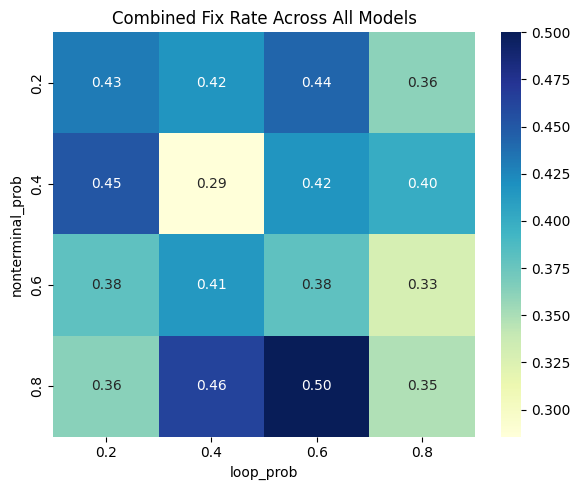

In [51]:
records = []
for db_path in sources_dbs:
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT nonterminal_prob, loop_prob, fix FROM repair_results', conn
    )
    conn.close()
    df_res['model'] = os.path.basename(db_path)
    records.append(df_res)

df_all = pd.concat(records, ignore_index=True)

# compute total & successful counts per (nonterminal_prob, loop_prob)
totals    = df_all.groupby(['nonterminal_prob','loop_prob']).size().rename('total')
successes = df_all[df_all['fix'] == 1] \
                    .groupby(['nonterminal_prob','loop_prob']).size().rename('success')
df_rate   = pd.concat([totals, successes],
axis=1).fillna(0)
df_rate['rate'] = df_rate['success'] / df_rate['total']

# pivot into heatmap-friendly form
pivot = df_rate['rate'].unstack(level='loop_prob')

# plot
plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Combined Fix Rate Across All Models')
plt.xlabel('loop_prob')
plt.ylabel('nonterminal_prob')
plt.tight_layout()

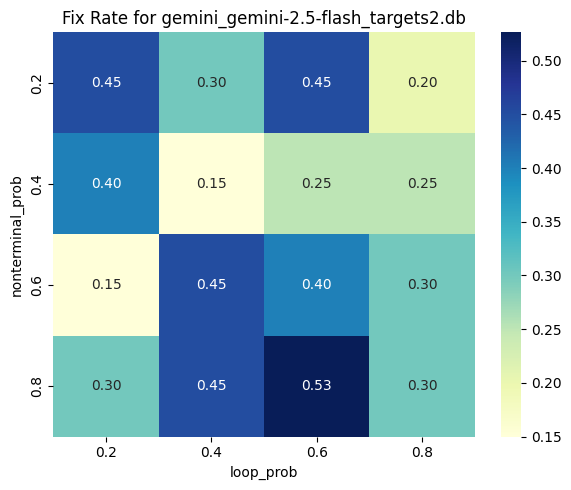

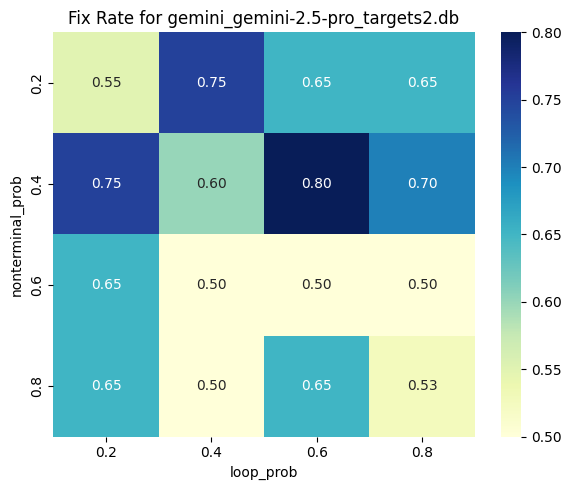

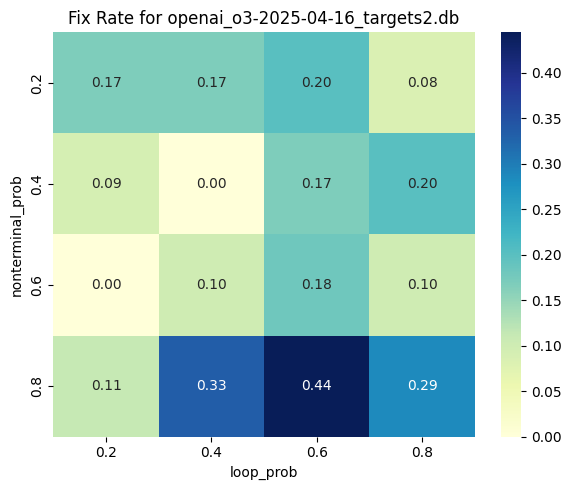

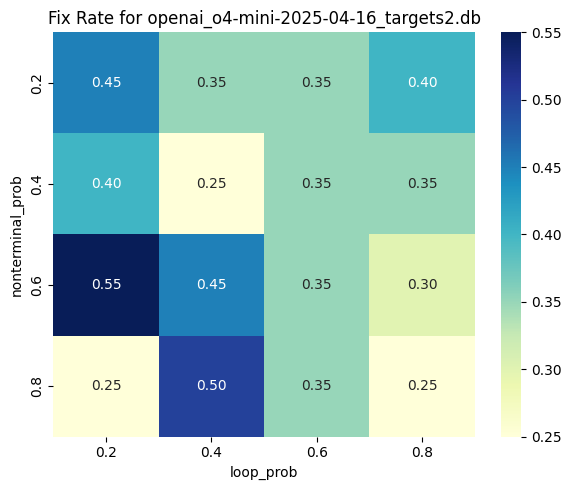

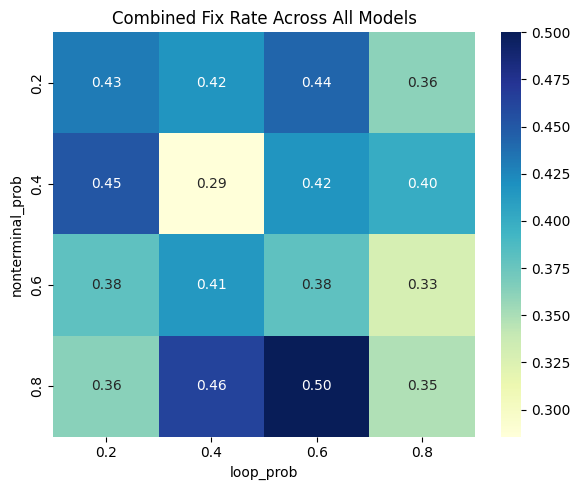

In [52]:
for db_path in sources_dbs:
        model = os.path.basename(db_path).removeprefix('repair_results_') \
                             .removesuffix('_targets.db')
        conn = sqlite3.connect(db_path)
        df_res = pd.read_sql(
            'SELECT nonterminal_prob, loop_prob, fix FROM repair_results',
            conn
        )
        conn.close()

        # Compute success rate per (nonterminal_prob, loop_prob)
        totals   = df_res.groupby(['nonterminal_prob','loop_prob']).size().rename('total')
        successes= df_res[df_res['fix'] == 1] \
                        .groupby(['nonterminal_prob','loop_prob']).size().rename('success')
        df_rate  = pd.concat([totals, successes], axis=1).fillna(0)
        df_rate['rate'] = df_rate['success'] / df_rate['total']

        # Pivot for heatmap
        pivot = df_rate['rate'].unstack(level='loop_prob')

        plt.figure(figsize=(6, 5))
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
        plt.title(f'Fix Rate for {model}')
        plt.xlabel('loop_prob')
        plt.ylabel('nonterminal_prob')
        plt.tight_layout()

# Combined heatmap of fix-rate across all models by nonterminal_prob and loop_prob
records = []
for db_path in sources_dbs:
    conn = sqlite3.connect(db_path)
    df_res = pd.read_sql(
        'SELECT nonterminal_prob, loop_prob, fix FROM repair_results',
        conn
    )
    conn.close()
    df_res['model'] = os.path.basename(db_path)
    records.append(df_res)

df_all = pd.concat(records, ignore_index=True)

# Compute aggregated success rate
totals   = df_all.groupby(['nonterminal_prob','loop_prob']).size().rename('total')
successes= df_all[df_all['fix'] == 1] \
                .groupby(['nonterminal_prob','loop_prob']).size().rename('success')
df_rate  = pd.concat([totals, successes], axis=1).fillna(0)
df_rate['rate'] = df_rate['success'] / df_rate['total']

# Pivot for combined heatmap
pivot = df_rate['rate'].unstack(level='loop_prob')

plt.figure(figsize=(6, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Combined Fix Rate Across All Models')
plt.xlabel('loop_prob')
plt.ylabel('nonterminal_prob')
plt.tight_layout()


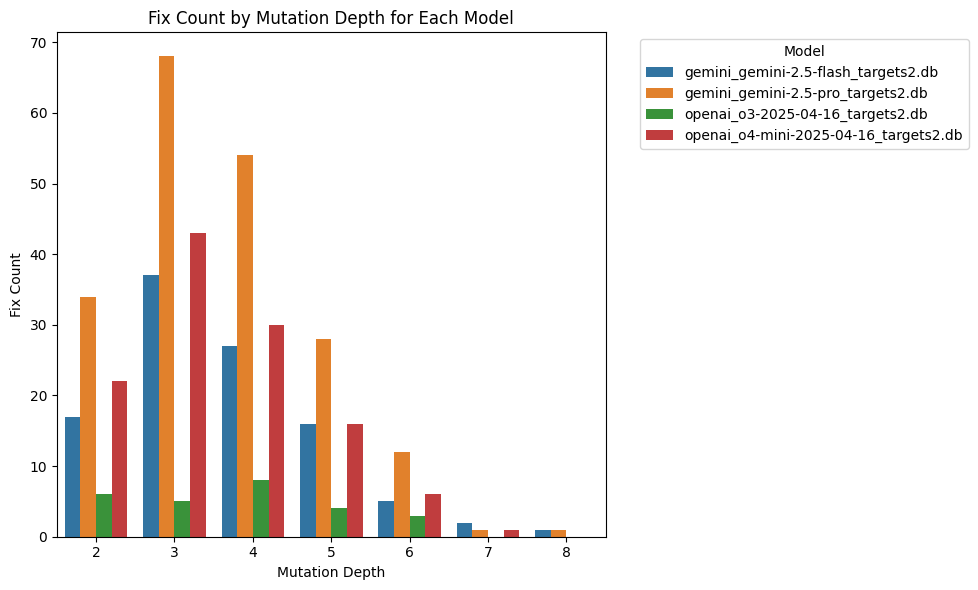

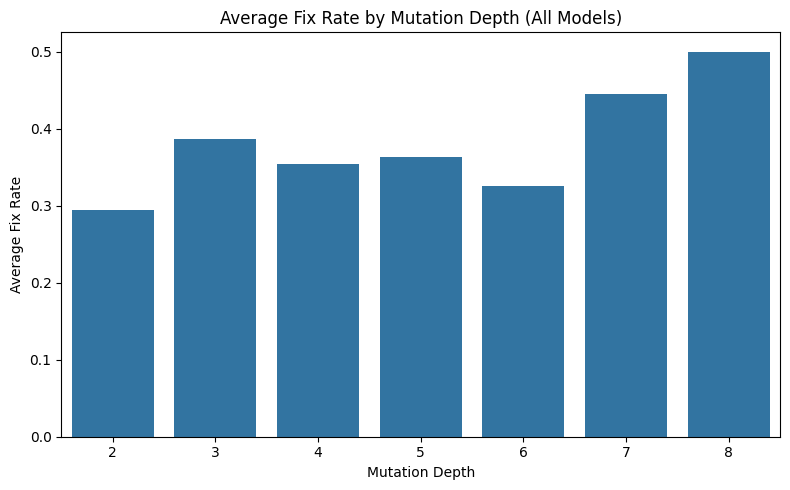

In [53]:
records = []
for db_path in sources_dbs:
    # extract model name from filename
    model = os.path.basename(db_path).removeprefix('repair_results_') \
                                        .removesuffix('_targets.db')
    conn = sqlite3.connect(db_path)
    try:
        df_res = pd.read_sql("SELECT case_id, fix FROM repair_results", conn)
    except pd.io.sql.DatabaseError:
        conn.close()
        continue
    conn.close()

    # keep only the cases where fix==1 and join mutation_depth from df_cases
    df_ok = df_res[df_res['fix'] == 1].merge(
        df_cases[['id','mutation_depth']],
        left_on='case_id', right_on='id'
    )
    counts = df_ok['mutation_depth'].value_counts().sort_index()
    for depth, cnt in counts.items():
        records.append({'model': model, 'mutation_depth': depth, 'accuracy': cnt})

df_counts = pd.DataFrame(records)
# compute fix rates by mutation_depth per model
total_cases = df_cases['mutation_depth'].value_counts().sort_index()
df_rates = df_counts.copy()
df_rates['total_cases'] = df_rates['mutation_depth'].map(total_cases)
df_rates['rate'] = df_rates['accuracy'] / df_rates['total_cases']

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_counts,
    x='mutation_depth',
    y='accuracy',
    hue='model',
    palette='tab10'
)
plt.xlabel('Mutation Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy by Mutation Depth for Each Model')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

df_comb = df_rates.groupby('mutation_depth')['rate'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_comb,
    x='mutation_depth',
    y='rate',
    color='C0'
)
plt.xlabel('Mutation Depth')
plt.ylabel('Average Fix Rate')
plt.title('Average Fix Rate by Mutation Depth (All Models)')
plt.tight_layout()

Pass@K

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

db_paths = [
    "repair_results_openai_gpt-4o-2024-08-06_targets.db"
]
ks = list(range(1, 11))
records = []

for db_path in db_paths:
    model = os.path.splitext(os.path.basename(db_path))[0]
    conn = sqlite3.connect(db_path)

    # Skip if there's no repair_results table
    existing = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table' AND name='repair_results'",
        conn
    )
    if existing.empty:
        print(f"{db_path} has no repair_results table, skipping…")
        conn.close()
        continue

    # Check if 'sample' column exists
    info = pd.read_sql("PRAGMA table_info(repair_results)", conn)
    has_sample = 'sample' in info['name'].tolist()

    # Read required columns
    cols = "puzzle_id, fix" + (", sample" if has_sample else "")
    df = pd.read_sql(f"SELECT {cols} FROM repair_results", conn)
    conn.close()

    # If no sample column, assign sample numbers by puzzle_id occurrence order
    if not has_sample:
        df['sample'] = df.groupby('puzzle_id').cumcount() + 1

    total = df['puzzle_id'].nunique()
    for k in ks:
        df_k = df[df['sample'] <= k]
        # For each puzzle_id, if any of the first k attempts fixed it, count as passed
        passed = df_k.groupby('puzzle_id')['fix'].max().sum()
        rate = passed / total
        records.append({"model": model, "k": k, "rate": rate})

df_pass_k = pd.DataFrame(records)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pass_k, x='k', y='rate', hue='model', marker='o')
plt.xticks(ks, rotation=45)
plt.xlabel('k (max attempts)')
plt.ylabel('Pass@k Rate')
plt.title('Pass@k Rate per Model (from targets4 DB, sample by puzzle_id order)')
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

repair_results_repair_results_openai_gpt-4o-2024-08-06_targets.db_targets4.db has no repair_results table, skipping…


ValueError: Could not interpret value `k` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>